# 03 — See & move

A picture of the world goes in, a motor command comes out: `PanoramicFrame → EyeSampler → flyvis → FlyvisBridge → LIFBrain → Readout`.
Read `docs/03-see-and-move.md` alongside — especially section 5 for what works (the optomotor turn) and what does not yet (the looming escape).

Needs `data/raw`, the pretrained flyvis models (`uv run flyvis download-pretrained`) and `data/cache/alignment.parquet` (`uv run python scripts/build_alignment.py`).

In [1]:
import os, sys; sys.path.insert(0, "..")
os.environ["FLYVIS_ROOT_DIR"] = os.path.abspath("../data/flyvis")   # .env is relative to the repo root
import numpy as np, polars as pl, torch
from flyhigh.data.connectome import Connectome
from flyhigh.agent import FlyAgent
from flyhigh.senses.frame import PanoramicFrame, looming_disc, rotating_grating
from flyvis.analysis.visualization.plots import hex_scatter
import matplotlib as mpl, matplotlib.pyplot as plt
# dataviz conventions: fixed categorical order, single-hue sequential, thin marks, recessive grid
C = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
                     "axes.prop_cycle": mpl.cycler(color=C), "lines.linewidth": 2, "font.size": 10})
c = Connectome.load("../data/raw")
agent = FlyAgent(c, n_agents=1, alignment_path="../data/cache/alignment.parquet")
print(f"driven LIF neurons: {len(agent.bridge.driven_indices):,}   flyvis neurons per eye: {agent.eye.n_neurons:,}")

LC = c.ids_by_type(r"^(LC4|LPLC2)$")

def play(frames, watch=()):
    """Run frames after 300 ms of grey. Returns per-tick commands, spike counts of `watch` neurons, and LC4+LPLC2 spikes."""
    for _ in range(30): agent.tick([PanoramicFrame.grey()])
    cmds, spikes, lc = [], [], []
    for fr in frames:
        cmds.append(agent.tick([fr])[0]); spikes.append(agent.brain_counts_last_tick[list(watch)].copy()); lc.append(agent.brain_counts_last_tick[LC].sum())
    return cmds, np.array(spikes), np.array(lc)

/home/martin/dev_works/Side_Projects/Flyhigh/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-09-19 22:10:47] network_view:122 Initialized network view at /home/martin/dev_works/Side_Projects/Flyhigh/data/flyvis/results/flow/0000/000


[2026-09-19 22:10:47] logging_utils:23 epe not in /home/martin/dev_works/Side_Projects/Flyhigh/data/flyvis/results/flow/0000/000/validation, but 'loss' is. Falling back to 'loss'. You can rerun the ensemble validation to make appropriate recordings of the losses.


[2026-09-19 22:10:53] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.


[2026-09-19 22:10:53] chkpt_utils:36 Recovered network state.


driven LIF neurons: 56,218   flyvis neurons per eye: 45,669


## 1. What the eyes see
A looming disc at azimuth +60° (right of straight ahead), sampled onto the two 721-column eyes. Each hexagon is one column; the right eye looks at the disc, the left sees grey.

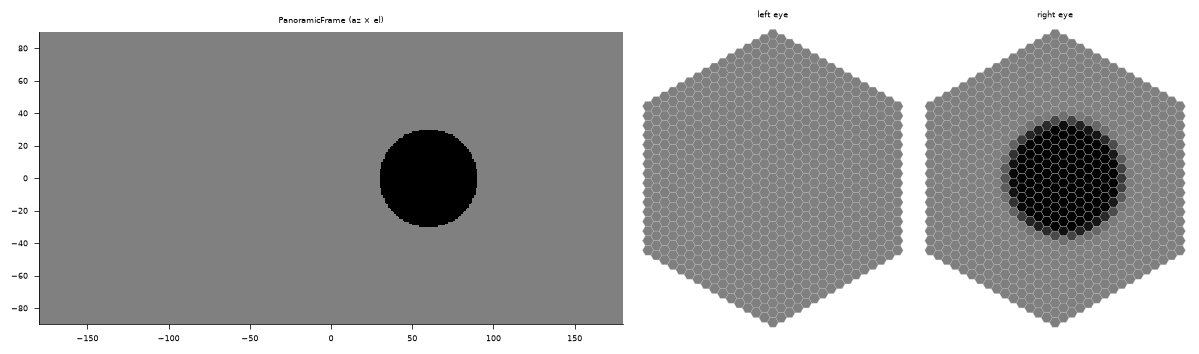

In [2]:
frame = looming_disc(az=60, el=0, start_deg=5, end_deg=60, duration_ms=500)[-1]
lum = agent.sampler.sample(frame)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), gridspec_kw={"width_ratios": [2.2, 1, 1]})
axes[0].imshow(frame.lum, cmap="gray", vmin=0, vmax=1, extent=[-180, 180, -90, 90]); axes[0].set_title("PanoramicFrame (az × el)"); axes[0].grid(False)
for ax, eye, name in zip(axes[1:], agent.sampler.eyes, ("left eye", "right eye")):
    hex_scatter(eye.u, eye.v, lum[0 if name == "left eye" else 1], fig=fig, ax=ax, cmap=plt.get_cmap("gray"), vmin=0, vmax=1, cbar=False, edgecolor="#bbb", edgewidth=0.2)
    ax.set_title(name); ax.axis("off")
plt.tight_layout()

## 2. flyvis computes direction
Run a rotating grating through the eyes and look at the T4a (front-to-back) and T4b (back-to-front) maps on the right eye. Clockwise rotation is front-to-back on the right eye, so T4a lights up; anticlockwise flips it.

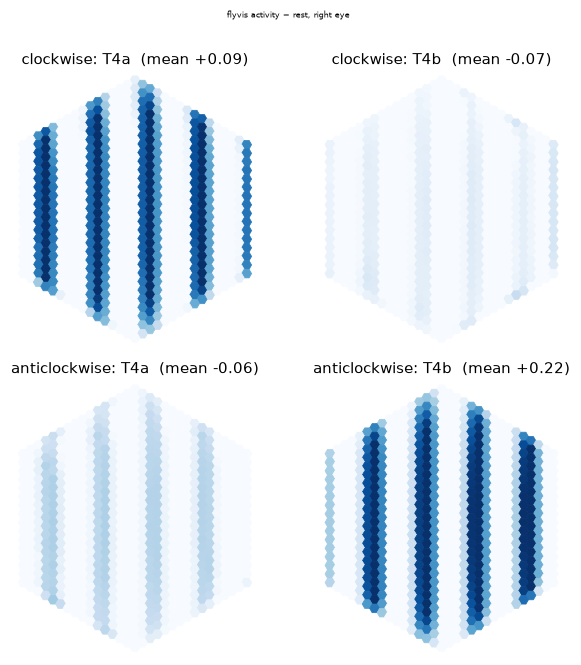

In [3]:
def flyvis_map(frames, cell_type, eye_row=1):
    for _ in range(30): agent.eye.step(torch.full((2, 721), 0.5, device=agent.eye.device))
    acts = []
    for fr in frames:
        a = agent.eye.step(torch.as_tensor(agent.sampler.sample(fr), device=agent.eye.device))
        acts.append(a.cpu().numpy()[eye_row] - agent.eye.rest)
    m = agent.eye.types == cell_type
    return np.mean(acts[20:], axis=0)[m], agent.eye.u[m], agent.eye.v[m]

fig, axes = plt.subplots(2, 2, figsize=(6, 6))
for i, (d, name) in enumerate(((+1, "clockwise"), (-1, "anticlockwise"))):
    frames = rotating_grating(30, 60, 400, direction=d)
    for j, t in enumerate(("T4a", "T4b")):
        vals, u, v = flyvis_map(frames, t)
        hex_scatter(u, v, vals, fig=fig, ax=axes[i, j], cmap=plt.get_cmap("Blues"), vmin=0, vmax=1.2, cbar=False, edgecolor=None)
        axes[i, j].set_title(f"{name}: {t}  (mean {vals.mean():+.2f})", fontsize=10); axes[i, j].axis("off")
plt.suptitle("flyvis activity − rest, right eye", y=1.0); plt.tight_layout()

## 3. Descending neurons during a looming disc
Spikes per 10 ms tick of the neurons the readout watches. The giant fiber (`DNp01`) should fire before the disc reaches 40° — in this brain it does not: LC4/LPLC2 are under-driven (see the doc, section 5).

escape ticks: 0   LC4+LPLC2 spikes during the loom: 0 (311 cells, 500 ms)


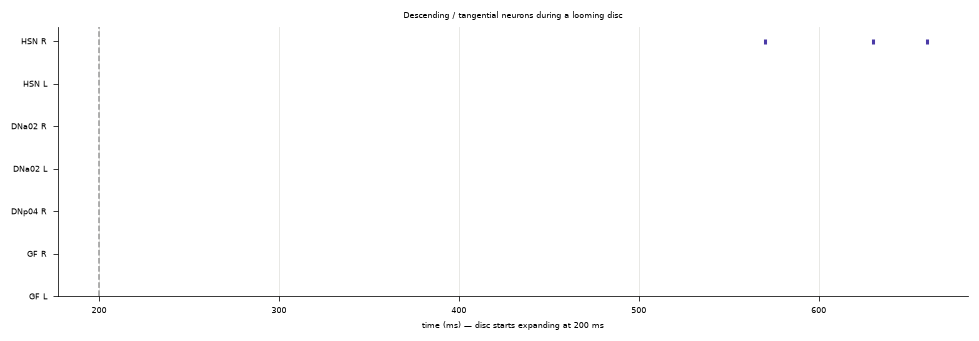

In [4]:
side = c.neurons["side"].to_numpy()
def one(pattern, s): idx = c.ids_by_type(pattern); return int(idx[side[idx] == s][0])
watch = {"GF L": one(r"^DNp01$", "L"), "GF R": one(r"^DNp01$", "R"), "DNp04 R": one(r"^DNp04$", "R"),
         "DNa02 L": one(r"^DNa02$", "L"), "DNa02 R": one(r"^DNa02$", "R"), "HSN L": one(r"^HSN$", "L"), "HSN R": one(r"^HSN$", "R")}
loom = [PanoramicFrame.grey()] * 20 + looming_disc(az=60, el=0, start_deg=5, end_deg=60, duration_ms=500)
cmds, spikes, lc = play(loom, watch.values())
fig, ax = plt.subplots(figsize=(9, 3.2))
for k, (name, _) in enumerate(watch.items()):
    t = np.nonzero(spikes[:, k])[0]
    ax.scatter(t * 10, np.full_like(t, k), s=12 * spikes[t, k], marker="|", color=C[k % len(C)])
ax.set_yticks(range(len(watch))); ax.set_yticklabels(list(watch)); ax.axvline(200, color="#999", lw=1, ls="--")
ax.set_xlabel("time (ms) — disc starts expanding at 200 ms"); ax.set_title("Descending / tangential neurons during a looming disc"); ax.grid(axis="y", visible=False)
plt.tight_layout()
print(f"escape ticks: {sum(cm.escape for cm in cmds)}   LC4+LPLC2 spikes during the loom: {int(lc.sum())} (311 cells, 500 ms)")

## 4. The commands
`yaw` and `escape` over time for grey, the looming disc, and a clockwise grating. The optomotor response is the fly turning *with* the scene (+ = right).

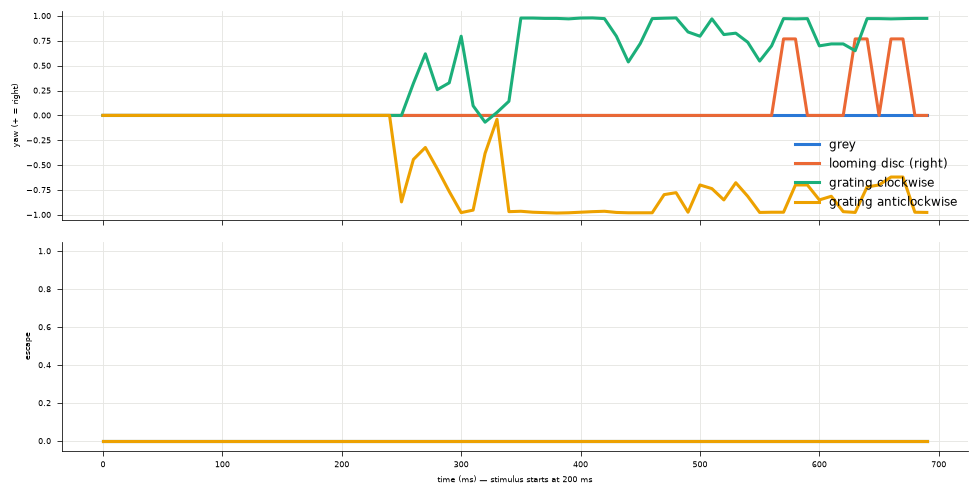

In [5]:
stims = {"grey": [PanoramicFrame.grey()] * 70, "looming disc (right)": loom,
         "grating clockwise": [PanoramicFrame.grey()] * 20 + rotating_grating(30, 60, 500, +1),
         "grating anticlockwise": [PanoramicFrame.grey()] * 20 + rotating_grating(30, 60, 500, -1)}
fig, axes = plt.subplots(2, 1, figsize=(9, 4.6), sharex=True)
for k, (name, frames) in enumerate(stims.items()):
    cmds, _, _ = play(frames)
    t = np.arange(len(cmds)) * 10
    axes[0].plot(t, [cm.yaw for cm in cmds], label=name, color=C[k]); axes[1].plot(t, [float(cm.escape) for cm in cmds], color=C[k])
axes[0].set_ylabel("yaw (+ = right)"); axes[0].set_ylim(-1.05, 1.05); axes[0].legend(loc="lower right", fontsize=8)
axes[1].set_ylabel("escape"); axes[1].set_xlabel("time (ms) — stimulus starts at 200 ms"); axes[1].set_ylim(-0.05, 1.05)
plt.tight_layout()

## 5. How fast is it?
One tick = one 10 ms frame = 1 flyvis step + 100 LIF steps + the readout.

In [6]:
import time
frames = [PanoramicFrame.grey()] * 50
play(frames[:5])
torch.cuda.synchronize(); t = time.perf_counter(); play(frames); torch.cuda.synchronize()
tps = 50 / (time.perf_counter() - t)
print(f"1 agent: {tps:.1f} ticks/s  →  {tps / 100:.2f}× real time (100 Hz camera)")

1 agent: 22.4 ticks/s  →  0.22× real time (100 Hz camera)


## Try it
- Move the disc: `looming_disc(az=-60, ...)` — the left eye's HS/T4 should mirror everything.
- `FlyAgent(c, gains={"T4a": 40, "T4b": 40, ...})` — raise the T4/T5 gain and watch the giant fiber start firing for the *grating* (section 3 of the doc).
- Swap ensemble member: `FlyvisEye(model="flow/0000/007")` — flyvis has 50; T4d is weak in member 0.